In [19]:
import pandas as pd

df = pd.read_csv("../Data/featured_engineering_dataset.csv")

print(df.shape)
df.head()

(122, 114)


,house_number,name,phone_number,area,family_size,meat_days,milk_per_week,vegetable_frequency,grocery_frequency,milk_per_person,...,rice_bullet_rice,rice_idli_dosa_rice,rice_jeerige_sanna,rice_madhusanna,rice_red_rice_rajamudi,rice_sona_masuri,rice_white_rice,rice_per_month,rice_per_day,rice_per_person
0,201,p mahema sai,9739697840,doddakallasandra,4.0,wednesday;friday;sunday,5.0,3.0,4.0,1.25,...,0,0,0,0,0,0,1,6.0,0.5,1.5
1,20,namitha n reddy,9108291205,koramangala,5.0,not_applicable,5.0,4.0,3.0,1.00,...,0,0,0,0,0,0,1,6.0,0.5,1.2
2,703,n,9876512349,doddakallasandra,4.0,not_applicable,3.0,3.0,4.0,0.75,...,0,1,0,0,0,1,1,6.0,0.5,1.5
3,251,shobhika santhosh,7022167063,hsr,3.0,wednesday;friday;saturday;sunday,1.0,3.0,3.0,0.33,...,0,0,0,0,1,0,0,3.0,0.5,1.0
4,147,NaN,9513144130,vijayanagar,4.0,not_applicable,7.0,3.0,3.0,1.75,...,0,1,0,0,0,1,1,6.0,0.5,1.5


In [20]:
print("rice_per_month" in df.columns)

True


In [21]:
rice_df = df.copy()

In [22]:
rice_df.drop(
    columns=[
        "house_number",
        "name",
        "phone_number",
        "area",
        "rice_per_day",
        "rice_per_person"
    ],
    inplace=True,
    errors="ignore"
)
rice_df.drop(columns=["meat_days"], inplace=True, errors="ignore")
remove_prefixes = [
    "veg_",
    "fruit_",
    "grain_",
    "dairy_",
    "store_"
]

cols = []

for prefix in remove_prefixes:
    cols.extend([c for c in rice_df.columns if c.startswith(prefix)])

rice_df.drop(columns=cols, inplace=True)

In [23]:
print(rice_df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [24]:
rice_df.head()


,family_size,milk_per_week,vegetable_frequency,grocery_frequency,milk_per_person,vegetable_count,fruits_apple,fruits_banana,fruits_blue_berry,fruits_grapes,...,rice_black_rice,rice_brown_rice,rice_bullet_rice,rice_idli_dosa_rice,rice_jeerige_sanna,rice_madhusanna,rice_red_rice_rajamudi,rice_sona_masuri,rice_white_rice,rice_per_month
0,4.0,5.0,3.0,4.0,1.25,6,1,1,0,1,...,0,1,0,0,0,0,0,0,1,6.0
1,5.0,5.0,4.0,3.0,1.00,7,1,1,0,0,...,0,0,0,0,0,0,0,0,1,6.0
2,4.0,3.0,3.0,4.0,0.75,5,1,1,0,0,...,0,1,0,1,0,0,0,1,1,6.0
3,3.0,1.0,3.0,3.0,0.33,8,1,1,0,0,...,0,0,0,0,0,0,1,0,0,3.0
4,4.0,7.0,3.0,3.0,1.75,5,1,1,0,0,...,0,0,0,1,0,0,0,1,1,6.0


In [25]:
y = rice_df["rice_per_month"]

X = rice_df.drop(columns=["rice_per_month"])

In [26]:
print(X.shape)
print(y.shape)

(122, 47)
(122,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(97, 47)
(25, 47)


In [28]:
print(X_train.isna().sum().sum())

0


In [29]:
#Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred = lr_model.predict(X_test)

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*45)
print("Linear Regression Results")
print("="*45)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Linear Regression Results
MAE  : 6.095
RMSE : 7.256
R²   : -1.042


In [33]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred,2)
})

results.head(15)

,Actual,Predicted
0,3.0,13.17
1,14.0,20.99
2,10.0,-1.79
3,6.0,7.86
4,6.0,10.51
5,3.0,12.96
6,18.0,19.40
7,6.0,13.60
8,10.0,14.18
9,18.0,27.81


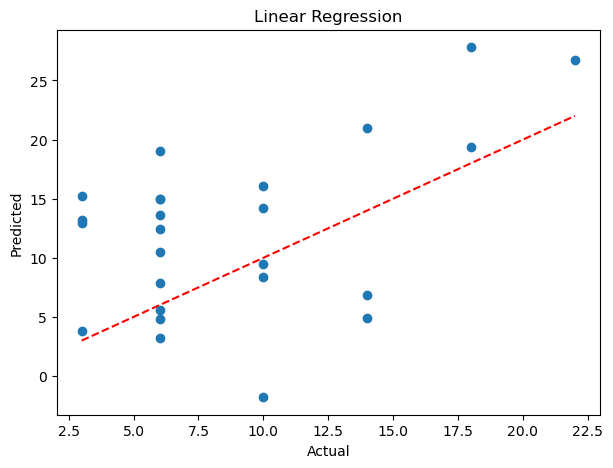

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")

plt.show()

In [35]:
#Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [37]:
y_pred = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*45)
print("Random Forest Results")
print("="*45)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Random Forest Results
MAE  : 4.088
RMSE : 5.043
R²   : 0.014


In [39]:
#XGBoost

In [40]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [41]:
y_pred = xgb_model.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*45)
print("XGBoost Results")
print("="*45)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

XGBoost Results
MAE  : 5.167
RMSE : 6.299
R²   : -0.539


In [43]:
#catboost

In [44]:
!pip install catboost

In [45]:
from catboost import CatBoostRegressor

In [46]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

In [47]:
cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [48]:
y_pred = cat_model.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*45)
print("CatBoost Results")
print("="*45)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

CatBoost Results
MAE  : 4.501
RMSE : 5.252
R²   : -0.070


In [50]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1,milk_per_week,0.162312
0,family_size,0.137173
5,vegetable_count,0.117640
4,milk_per_person,0.057976
25,fruits_watermelon,0.056711
19,fruits_papaya,0.045769
44,rice_red_rice_rajamudi,0.038713
33,zone_East,0.027582
23,fruits_pomegranate,0.026110
45,rice_sona_masuri,0.022841


In [51]:
import joblib
import os

os.makedirs("../Models", exist_ok=True)

joblib.dump(rf_model, "../Models/rice_consumption_rf.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [52]:
import joblib

joblib.dump(X.columns.tolist(),
            "../Models/model_columns.pkl")

['../Models/model_columns.pkl']

In [53]:
import joblib

model = joblib.load("Models/rice_consumption_rf.pkl")

print(hasattr(model, "feature_names_in_"))

FileNotFoundError: [Errno 2] No such file or directory: 'Models/rice_consumption_rf.pkl'